Linear probe

Resnet50

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: RESNET50 - LAST BLOCK FINE-TUNING
#########################################

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

def freeze_backbone(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier
    for param in model.fc.parameters():
        param.requires_grad = True

freeze_backbone(model)

# Log frozen/unfrozen parameter counts
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {total_params - trainable_params:,}")
print(f"% Unfrozen            : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    # Average gradient norms over batches
    num_batches = len(loader)
    avg_grad_norms = {k: v / num_batches for k, v in epoch_grad_norms.items()}

    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []   # one dict per epoch
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "resnet50_linearprobe.pth")
torch.save(history, "resnet50_linearprobe_history.pth")
print("Saved resnet50_linearprobe.pth and resnet50_linearprobe_history.pth")

Total parameters      : 23,569,502
Trainable parameters  : 61,470
Frozen parameters     : 23,508,032
% Unfrozen            : 0.26%
Starting Last Block Fine-Tuning on cuda
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 2.9656 | Train: 0.2917 | Val: 0.5529


Epoch 02/20 | Loss: 2.2193 | Train: 0.6456 | Val: 0.7145


Epoch 03/20 | Loss: 1.7457 | Train: 0.7401 | Val: 0.7788


Epoch 04/20 | Loss: 1.4221 | Train: 0.7943 | Val: 0.8022


...

Epoch 16/20 | Loss: 0.5522 | Train: 0.8866 | Val: 0.8594


Epoch 17/20 | Loss: 0.5364 | Train: 0.8825 | Val: 0.8603


Epoch 18/20 | Loss: 0.5110 | Train: 0.8901 | Val: 0.8589


Epoch 19/20 | Loss: 0.4933 | Train: 0.8938 | Val: 0.8608


Epoch 20/20 | Loss: 0.4790 | Train: 0.8948 | Val: 0.8618
Saved resnet50_linearprobe.pth and resnet50_linearprobe_history.pth


EfficientNet

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: EFFICIENTNET-B0 - LAST BLOCK FINE-TUNING
#########################################

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

def freeze_backbone(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_backbone(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: EfficientNet-B0")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "efficientnet_b0_linearprobe.pth")
torch.save(history, "efficientnet_b0_linearprobe_history.pth")
print("Saved efficientnet_b0_linearprobe.pth and efficientnet_b0_linearprobe_history.pth")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Total parameters     : 4,045,978
Trainable parameters : 38,430
Frozen parameters    : 4,007,548
% Unfrozen           : 0.95%
Starting Last Block Fine-Tuning on cuda
Model: EfficientNet-B0
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 3.1540 | Train: 0.1947 | Val: 0.4561


Epoch 02/20 | Loss: 2.7143 | Train: 0.4927 | Val: 0.6182


...

Epoch 16/20 | Loss: 0.9197 | Train: 0.8086 | Val: 0.8051


Epoch 17/20 | Loss: 0.8885 | Train: 0.8151 | Val: 0.8065


Epoch 18/20 | Loss: 0.8649 | Train: 0.8123 | Val: 0.8051


Epoch 19/20 | Loss: 0.8394 | Train: 0.8174 | Val: 0.8051


Epoch 20/20 | Loss: 0.8073 | Train: 0.8288 | Val: 0.8165
Saved efficientnet_b0_linearprobe.pth and efficientnet_b0_linearprobe_history.pth


ConvNext

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: CONVNEXT-TINY - LAST BLOCK FINE-TUNING
#########################################

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

def freeze_backbone(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_backbone(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss       = 0
    correct          = 0
    total            = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: ConvNeXt-Tiny")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "convnext_tiny_linearprobe.pth")
torch.save(history, "convnext_tiny_linearprobe_history.pth")
print("Saved convnext_tiny_linearprobe.pth and convnext_tiny_linearprobe_history.pth")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 178MB/s]  


Total parameters     : 27,843,198
Trainable parameters : 24,606
Frozen parameters    : 27,818,592
% Unfrozen           : 0.09%
Starting Last Block Fine-Tuning on cuda
Model: ConvNeXt-Tiny
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 3.0072 | Train: 0.2605 | Val: 0.5400


Epoch 02/20 | Loss: 2.1872 | Train: 0.6574 | Val: 0.7388


...

Epoch 16/20 | Loss: 0.3541 | Train: 0.9295 | Val: 0.9042


Epoch 17/20 | Loss: 0.3289 | Train: 0.9367 | Val: 0.9056


Epoch 18/20 | Loss: 0.3122 | Train: 0.9391 | Val: 0.9104


Epoch 19/20 | Loss: 0.2957 | Train: 0.9414 | Val: 0.9104


Epoch 20/20 | Loss: 0.2839 | Train: 0.9418 | Val: 0.9113
Saved convnext_tiny_linearprobe.pth and convnext_tiny_linearprobe_history.pth


Last block fine tuning

Resnet50

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: RESNET50 - LAST BLOCK FINE-TUNING
#########################################

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

def freeze_except_last_block(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layer4 (last residual block) and classifier
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

freeze_except_last_block(model)

# Log frozen/unfrozen parameter counts
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {total_params - trainable_params:,}")
print(f"% Unfrozen            : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    # Average gradient norms over batches
    num_batches = len(loader)
    avg_grad_norms = {k: v / num_batches for k, v in epoch_grad_norms.items()}

    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 15

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []   # one dict per epoch
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "resnet50_lastblock.pth")
torch.save(history, "resnet50_lastblock_history.pth")
print("Saved resnet50_lastblock.pth and resnet50_lastblock_history.pth")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Total parameters      : 23,569,502
Trainable parameters  : 15,026,206
Frozen parameters     : 8,543,296
% Unfrozen            : 63.75%
Starting Last Block Fine-Tuning on cuda
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/30 | Loss: 1.0405 | Train: 0.7583 | Val: 0.9256


Epoch 02/30 | Loss: 0.2281 | Train: 0.9410 | Val: 0.9309


...

Epoch 26/30 | Loss: 0.0271 | Train: 0.9914 | Val: 0.9309


Epoch 27/30 | Loss: 0.0339 | Train: 0.9906 | Val: 0.9366


Epoch 28/30 | Loss: 0.0178 | Train: 0.9947 | Val: 0.9423


Epoch 29/30 | Loss: 0.0202 | Train: 0.9939 | Val: 0.9433


Epoch 30/30 | Loss: 0.0224 | Train: 0.9939 | Val: 0.9318
Saved resnet50_lastblock.pth and resnet50_lastblock_history.pth


EfficientNet

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: EFFICIENTNET-B0 - LAST BLOCK FINE-TUNING
#########################################

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

def freeze_except_last_block(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # EfficientNet features is a Sequential of MBConv blocks (0-8)
    # Block 8 is the last MBConv block — unfreeze it
    for param in model.features[8].parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_except_last_block(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 30

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: EfficientNet-B0")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "efficientnet_b0_lastblock.pth")
torch.save(history, "efficientnet_b0_lastblock_history.pth")
print("Saved efficientnet_b0_lastblock.pth and efficientnet_b0_lastblock_history.pth")

Total parameters     : 4,045,978
Trainable parameters : 450,590
Frozen parameters    : 3,595,388
% Unfrozen           : 11.14%
Starting Last Block Fine-Tuning on cuda
Model: EfficientNet-B0
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/30 | Loss: 2.9948 | Train: 0.3291 | Val: 0.6106


Epoch 02/30 | Loss: 2.2345 | Train: 0.6398 | Val: 0.7092


Epoch 03/30 | Loss: 1.6551 | Train: 0.7263 | Val: 0.7579


Epoch 04/30 | Loss: 1.2879 | Train: 0.7730 | Val: 0.7841


...

Epoch 26/30 | Loss: 0.2257 | Train: 0.9442 | Val: 0.8827


Epoch 27/30 | Loss: 0.2197 | Train: 0.9485 | Val: 0.8837


Epoch 28/30 | Loss: 0.2068 | Train: 0.9530 | Val: 0.8837


Epoch 29/30 | Loss: 0.2026 | Train: 0.9512 | Val: 0.8870


Epoch 30/30 | Loss: 0.1862 | Train: 0.9569 | Val: 0.8870
Saved efficientnet_b0_lastblock.pth and efficientnet_b0_lastblock_history.pth


ConvNext

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: CONVNEXT-TINY - LAST BLOCK FINE-TUNING
#########################################

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

def freeze_except_last_block(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # ConvNeXt-Tiny features structure:
    # features[0] - stem (Conv + LN)
    # features[1] - stage 1 (2 ConvNeXt blocks)
    # features[2] - downsampling layer
    # features[3] - stage 2 (2 ConvNeXt blocks)
    # features[4] - downsampling layer
    # features[5] - stage 3 (6 ConvNeXt blocks)  <-- deepest stage
    # features[6] - downsampling layer
    # features[7] - stage 4 (2 ConvNeXt blocks)  <-- last block
    # Unfreeze features[7] (last ConvNeXt stage) and classifier
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_except_last_block(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss       = 0
    correct          = 0
    total            = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 15

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: ConvNeXt-Tiny")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "convnext_tiny_lastblock.pth")
torch.save(history, "convnext_tiny_lastblock_history.pth")
print("Saved convnext_tiny_lastblock.pth and convnext_tiny_lastblock_history.pth")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 196MB/s]  


Total parameters     : 27,843,198
Trainable parameters : 14,314,014
Frozen parameters    : 13,529,184
% Unfrozen           : 51.41%
Starting Last Block Fine-Tuning on cuda
Model: ConvNeXt-Tiny
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/15 | Loss: 1.6281 | Train: 0.6613 | Val: 0.8994


Epoch 02/15 | Loss: 0.3565 | Train: 0.9326 | Val: 0.9423


...

Epoch 11/15 | Loss: 0.0155 | Train: 0.9988 | Val: 0.9561


Epoch 12/15 | Loss: 0.0164 | Train: 0.9975 | Val: 0.9566


Epoch 13/15 | Loss: 0.0182 | Train: 0.9965 | Val: 0.9590


Epoch 14/15 | Loss: 0.0173 | Train: 0.9963 | Val: 0.9604


Epoch 15/15 | Loss: 0.0153 | Train: 0.9963 | Val: 0.9609
Saved convnext_tiny_lastblock.pth and convnext_tiny_lastblock_history.pth


Full fine tuning

Resnet

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: RESNET50 - FULL FINE-TUNING
#########################################

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# All parameters are trainable — no freezing
for param in model.parameters():
    param.requires_grad = True

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss       = 0
    correct          = 0
    total            = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Full Fine-Tuning on {device}")
print(f"Model: ResNet50")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "resnet50_fullfinetune.pth")
torch.save(history, "resnet50_fullfinetune_history.pth")
print("Saved resnet50_fullfinetune.pth and resnet50_fullfinetune_history.pth")

Total parameters     : 23,569,502
Trainable parameters : 23,569,502
Frozen parameters    : 0
% Unfrozen           : 100.00%
Starting Full Fine-Tuning on cuda
Model: ResNet50
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 0.9824 | Train: 0.7628 | Val: 0.9180


Epoch 02/20 | Loss: 0.2468 | Train: 0.9318 | Val: 0.9276


Epoch 03/20 | Loss: 0.1264 | Train: 0.9692 | Val: 0.9395


Epoch 04/20 | Loss: 0.0919 | Train: 0.9761 | Val: 0.9147


...

Epoch 16/20 | Loss: 0.0370 | Train: 0.9890 | Val: 0.9380


Epoch 17/20 | Loss: 0.0795 | Train: 0.9753 | Val: 0.9194


Epoch 18/20 | Loss: 0.0704 | Train: 0.9785 | Val: 0.9266


Epoch 19/20 | Loss: 0.0398 | Train: 0.9882 | Val: 0.9180


Epoch 20/20 | Loss: 0.0385 | Train: 0.9890 | Val: 0.9447
Saved resnet50_fullfinetune.pth and resnet50_fullfinetune_history.pth


Efficient Net

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: EFFICIENTNET-B0 - LAST BLOCK FINE-TUNING
#########################################

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: EfficientNet-B0")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "efficientnet_b0_fullfinetune.pth")
torch.save(history, "efficientnet_b0_fullfinetune_history.pth")
print("Saved efficientnet_b0_fullfinetune.pth and efficientnet_b0_fullfinetune_history.pth")

Total parameters     : 4,045,978
Trainable parameters : 4,045,978
Frozen parameters    : 0
% Unfrozen           : 100.00%
Starting Last Block Fine-Tuning on cuda
Model: EfficientNet-B0
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 2.2662 | Train: 0.5326 | Val: 0.8394


Epoch 02/20 | Loss: 0.6261 | Train: 0.8711 | Val: 0.9214


Epoch 03/20 | Loss: 0.2789 | Train: 0.9367 | Val: 0.9352


Epoch 04/20 | Loss: 0.1712 | Train: 0.9596 | Val: 0.9423


...

Epoch 16/20 | Loss: 0.0259 | Train: 0.9935 | Val: 0.9585


Epoch 17/20 | Loss: 0.0220 | Train: 0.9947 | Val: 0.9623


Epoch 18/20 | Loss: 0.0180 | Train: 0.9953 | Val: 0.9604


Epoch 19/20 | Loss: 0.0211 | Train: 0.9967 | Val: 0.9638


Epoch 20/20 | Loss: 0.0157 | Train: 0.9967 | Val: 0.9604
Saved efficientnet_b0_fullfinetune.pth and efficientnet_b0_fullfinetune_history.pth


ConvNext

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: CONVNEXT-TINY - LAST BLOCK FINE-TUNING
#########################################

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss       = 0
    correct          = 0
    total            = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: ConvNeXt-Tiny")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "convnext_tiny_fullfinetune.pth")
torch.save(history, "convnext_tiny_fullfinetune_history.pth")
print("Saved convnext_tiny_fullfinetune.pth and convnext_tiny_fullfinetune_history.pth")

Total parameters     : 27,843,198
Trainable parameters : 27,843,198
Frozen parameters    : 0
% Unfrozen           : 100.00%
Starting Last Block Fine-Tuning on cuda
Model: ConvNeXt-Tiny
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 1.0926 | Train: 0.7763 | Val: 0.9337


Epoch 02/20 | Loss: 0.1660 | Train: 0.9657 | Val: 0.9490


Epoch 03/20 | Loss: 0.0596 | Train: 0.9906 | Val: 0.9595


Epoch 04/20 | Loss: 0.0284 | Train: 0.9953 | Val: 0.9542


...

Epoch 16/20 | Loss: 0.0100 | Train: 0.9978 | Val: 0.9633


Epoch 17/20 | Loss: 0.0082 | Train: 0.9986 | Val: 0.9633


Epoch 18/20 | Loss: 0.0175 | Train: 0.9949 | Val: 0.9595


Epoch 19/20 | Loss: 0.0200 | Train: 0.9947 | Val: 0.9638


Epoch 20/20 | Loss: 0.0039 | Train: 0.9992 | Val: 0.9347
Saved convnext_tiny_fullfinetune.pth and convnext_tiny_fullfinetune_history.pth


Selective layer unfreezing

Resnet

In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

_sum = 0
# Check layer3 block sizes
for name, param in model.named_parameters():
    if 'layer3' in name and ('.3.' in name or '4' in name or '5' in name):
        print(f"{name}: {param.numel():,}")
        _sum += param.numel()

print('='*60)
print(_sum)

layer3.3.conv1.weight: 262,144
layer3.3.bn1.weight: 256
layer3.3.bn1.bias: 256
layer3.3.conv2.weight: 589,824
layer3.3.bn2.weight: 256
layer3.3.bn2.bias: 256
layer3.3.conv3.weight: 262,144
layer3.3.bn3.weight: 1,024
layer3.3.bn3.bias: 1,024
layer3.4.conv1.weight: 262,144
layer3.4.bn1.weight: 256
layer3.4.bn1.bias: 256
layer3.4.conv2.weight: 589,824
layer3.4.bn2.weight: 256
layer3.4.bn2.bias: 256
layer3.4.conv3.weight: 262,144
layer3.4.bn3.weight: 1,024
layer3.4.bn3.bias: 1,024
layer3.5.conv1.weight: 262,144
layer3.5.bn1.weight: 256
layer3.5.bn1.bias: 256
layer3.5.conv2.weight: 589,824
layer3.5.bn2.weight: 256
layer3.5.bn2.bias: 256
layer3.5.conv3.weight: 262,144
layer3.5.bn3.weight: 1,024
layer3.5.bn3.bias: 1,024
3351552


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: RESNET50 - LAST BLOCK FINE-TUNING
#########################################

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

def freeze_selective(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 blocks of layer3 (blocks 3, 4, 5)
    for param in model.layer3[3].parameters():
        param.requires_grad = True
    for param in model.layer3[4].parameters():
        param.requires_grad = True
    for param in model.layer3[5].parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.fc.parameters():
        param.requires_grad = True

freeze_selective(model)

# Log frozen/unfrozen parameter counts
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {total_params - trainable_params:,}")
print(f"% Unfrozen            : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    # Average gradient norms over batches
    num_batches = len(loader)
    avg_grad_norms = {k: v / num_batches for k, v in epoch_grad_norms.items()}

    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []   # one dict per epoch
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "resnet50_selective.pth")
torch.save(history, "resnet50_selective_history.pth")
print("Saved resnet50_selective.pth and resnet50_selective_history.pth")

Total parameters      : 23,569,502
Trainable parameters  : 3,413,022
Frozen parameters     : 20,156,480
% Unfrozen            : 14.48%
Starting Last Block Fine-Tuning on cuda
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 2.5285 | Train: 0.4488 | Val: 0.7493


Epoch 02/20 | Loss: 0.9976 | Train: 0.8204 | Val: 0.8765


Epoch 03/20 | Loss: 0.4934 | Train: 0.8968 | Val: 0.9261


Epoch 04/20 | Loss: 0.2781 | Train: 0.9414 | Val: 0.9323


...

Epoch 16/20 | Loss: 0.0253 | Train: 0.9953 | Val: 0.9490


Epoch 17/20 | Loss: 0.0291 | Train: 0.9933 | Val: 0.9476


Epoch 18/20 | Loss: 0.0256 | Train: 0.9949 | Val: 0.9471


Epoch 19/20 | Loss: 0.0189 | Train: 0.9971 | Val: 0.9509


Epoch 20/20 | Loss: 0.0131 | Train: 0.9980 | Val: 0.9423
Saved resnet50_selective.pth and resnet50_selective_history.pth


EfficientNet

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 30)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"20% budget: {int(0.2 * total_params):,}")
print("="*60)

_sum = 0
for name, param in model.named_parameters():
    print(f"{name}: {param.numel():,}")
    _sum += param.numel()

Total parameters: 4,045,978
20% budget: 809,195
features.0.0.weight: 864
features.0.1.weight: 32
features.0.1.bias: 32
features.1.0.block.0.0.weight: 288
features.1.0.block.0.1.weight: 32
features.1.0.block.0.1.bias: 32
features.1.0.block.1.fc1.weight: 256
features.1.0.block.1.fc1.bias: 8
features.1.0.block.1.fc2.weight: 256
features.1.0.block.1.fc2.bias: 32
features.1.0.block.2.0.weight: 512
features.1.0.block.2.1.weight: 16
features.1.0.block.2.1.bias: 16
features.2.0.block.0.0.weight: 1,536
features.2.0.block.0.1.weight: 96
features.2.0.block.0.1.bias: 96
features.2.0.block.1.0.weight: 864
features.2.0.block.1.1.weight: 96
features.2.0.block.1.1.bias: 96
features.2.0.block.2.fc1.weight: 384
features.2.0.block.2.fc1.bias: 4
features.2.0.block.2.fc2.weight: 384
features.2.0.block.2.fc2.bias: 96
features.2.0.block.3.0.weight: 2,304
features.2.0.block.3.1.weight: 24
features.2.0.block.3.1.bias: 24
features.2.1.block.0.0.weight: 3,456
features.2.1.block.0.1.weight: 144
features.2.1.block

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: EFFICIENTNET-B0 - LAST BLOCK FINE-TUNING
#########################################

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

def freeze_selective(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze features[4] (3 MBConv blocks, ~213K params)
    for param in model.features[4].parameters():
        param.requires_grad = True

    # Unfreeze features[5] (3 MBConv blocks, ~454K params)
    for param in model.features[5].parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_selective(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Collect gradient norms before stepping
        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: EfficientNet-B0")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "efficientnet_b0_selective.pth")
torch.save(history, "efficientnet_b0_selective_history.pth")
print("Saved efficientnet_b0_selective.pth and efficientnet_b0_selective_history.pth")

Total parameters     : 4,045,978
Trainable parameters : 824,508
Frozen parameters    : 3,221,470
% Unfrozen           : 20.38%
Starting Last Block Fine-Tuning on cuda
Model: EfficientNet-B0
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 3.0874 | Train: 0.2605 | Val: 0.5848


Epoch 02/20 | Loss: 2.3559 | Train: 0.6396 | Val: 0.7650


Epoch 03/20 | Loss: 1.6430 | Train: 0.7808 | Val: 0.8255


Epoch 04/20 | Loss: 1.1352 | Train: 0.8349 | Val: 0.8556


...

Epoch 16/20 | Loss: 0.1231 | Train: 0.9765 | Val: 0.9461


Epoch 17/20 | Loss: 0.1179 | Train: 0.9781 | Val: 0.9480


Epoch 18/20 | Loss: 0.1027 | Train: 0.9814 | Val: 0.9447


Epoch 19/20 | Loss: 0.1009 | Train: 0.9814 | Val: 0.9480


Epoch 20/20 | Loss: 0.0824 | Train: 0.9853 | Val: 0.9504
Saved efficientnet_b0_selective.pth and efficientnet_b0_selective_history.pth


ConvNext

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"20% budget: {int(0.2 * total_params):,}")
print("="*60)

# Print per stage summary
stages = ['features.0', 'features.1', 'features.2', 'features.3', 
          'features.4', 'features.5', 'features.6', 'features.7', 'classifier']

for stage in stages:
    stage_params = sum(p.numel() for name, p in model.named_parameters() if stage in name)
    print(f"{stage}: {stage_params:,}")

for name, param in model.named_parameters():
    if 'features.5' in name:
        print(f"{name}: {param.numel():,}")

# Also print per-block summary
print("="*60)
for i in range(len(model.features[5])):
    block_params = sum(p.numel() for name, p in model.named_parameters() if f'features.5.{i}.' in name)
    print(f"features.5.{i}: {block_params:,}")

Total parameters: 27,843,198
20% budget: 5,568,639
features.0: 4,896
features.1: 237,888
features.2: 74,112
features.3: 918,144
features.4: 295,680
features.5: 10,817,280
features.6: 1,181,184
features.7: 14,289,408
classifier: 24,606
features.5.0.layer_scale: 384
features.5.0.block.0.weight: 18,816
features.5.0.block.0.bias: 384
features.5.0.block.2.weight: 384
features.5.0.block.2.bias: 384
features.5.0.block.3.weight: 589,824
features.5.0.block.3.bias: 1,536
features.5.0.block.5.weight: 589,824
features.5.0.block.5.bias: 384
features.5.1.layer_scale: 384
features.5.1.block.0.weight: 18,816
features.5.1.block.0.bias: 384
features.5.1.block.2.weight: 384
features.5.1.block.2.bias: 384
features.5.1.block.3.weight: 589,824
features.5.1.block.3.bias: 1,536
features.5.1.block.5.weight: 589,824
features.5.1.block.5.bias: 384
features.5.2.layer_scale: 384
features.5.2.block.0.weight: 18,816
features.5.2.block.0.bias: 384
features.5.2.block.2.weight: 384
features.5.2.block.2.bias: 384
featur

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# DATA TRANSFORMS
#########################################

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#########################################
# DATASET
#########################################

train_dir = "/kaggle/input/datasets/mvpranay/aid-dataset/train_data"

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full   = datasets.ImageFolder(train_dir, transform=val_transform)

train_size = int(0.7 * len(train_full))
val_size   = len(train_full) - train_size

torch.manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_full, [train_size, val_size])
torch.manual_seed(42)
_, val_dataset   = torch.utils.data.random_split(val_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, persistent_workers=True)

num_classes = len(train_full.classes)

#########################################
# MODEL: CONVNEXT-TINY - LAST BLOCK FINE-TUNING
#########################################

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

def freeze_selective(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 blocks of features.5 (blocks 6, 7, 8 — ~3.6M params)
    for param in model.features[5][6].parameters():
        param.requires_grad = True
    for param in model.features[5][7].parameters():
        param.requires_grad = True
    for param in model.features[5][8].parameters():
        param.requires_grad = True

    # Unfreeze features.6 (downsampling layer — ~1.18M params)
    for param in model.features[6].parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

freeze_selective(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"% Unfrozen           : {100 * trainable_params / total_params:.2f}%")

model = model.to(device)

#########################################
# LOSS + OPTIMIZER
#########################################

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

#########################################
# GRADIENT NORM TRACKING
#########################################

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

#########################################
# TRAINING LOOP
#########################################

def train_epoch(model, loader):
    model.train()
    total_loss       = 0
    correct          = 0
    total            = 0
    epoch_grad_norms = {}

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        batch_norms = get_gradient_norms(model)
        for k, v in batch_norms.items():
            epoch_grad_norms[k] = epoch_grad_norms.get(k, 0) + v

        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    avg_grad_norms = {k: v / len(loader) for k, v in epoch_grad_norms.items()}
    return total_loss / len(loader), correct / total, avg_grad_norms

#########################################
# VALIDATION LOOP
#########################################

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

#########################################
# MAIN TRAINING
#########################################

epochs = 20

history = {
    'train_loss': [],
    'train_acc':  [],
    'val_acc':    [],
    'grad_norms': []
}

print(f"Starting Last Block Fine-Tuning on {device}")
print(f"Model: ConvNeXt-Tiny")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")
print("="*60)

for epoch in range(epochs):
    train_loss, train_acc, grad_norms = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['grad_norms'].append(grad_norms)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

#########################################
# SAVE MODEL + HISTORY
#########################################

torch.save(model.state_dict(), "convnext_tiny_selective.pth")
torch.save(history, "convnext_tiny_selective_history.pth")
print("Saved convnext_tiny_selective.pth and convnext_tiny_selective_history.pth")

Total parameters     : 27,843,198
Trainable parameters : 4,811,550
Frozen parameters    : 23,031,648
% Unfrozen           : 17.28%
Starting Last Block Fine-Tuning on cuda
Model: ConvNeXt-Tiny
Train: 4895 | Val: 2098 | Classes: 30


Epoch 01/20 | Loss: 1.6722 | Train: 0.6556 | Val: 0.9032


Epoch 02/20 | Loss: 0.3136 | Train: 0.9448 | Val: 0.9509


Epoch 03/20 | Loss: 0.1513 | Train: 0.9755 | Val: 0.9581


Epoch 04/20 | Loss: 0.0798 | Train: 0.9888 | Val: 0.9595


...

Epoch 16/20 | Loss: 0.0091 | Train: 0.9988 | Val: 0.9623


Epoch 17/20 | Loss: 0.0089 | Train: 0.9975 | Val: 0.9681


Epoch 18/20 | Loss: 0.0070 | Train: 0.9984 | Val: 0.9657


Epoch 19/20 | Loss: 0.0093 | Train: 0.9980 | Val: 0.9657


Epoch 20/20 | Loss: 0.0095 | Train: 0.9980 | Val: 0.9685
Saved convnext_tiny_selective.pth and convnext_tiny_selective_history.pth


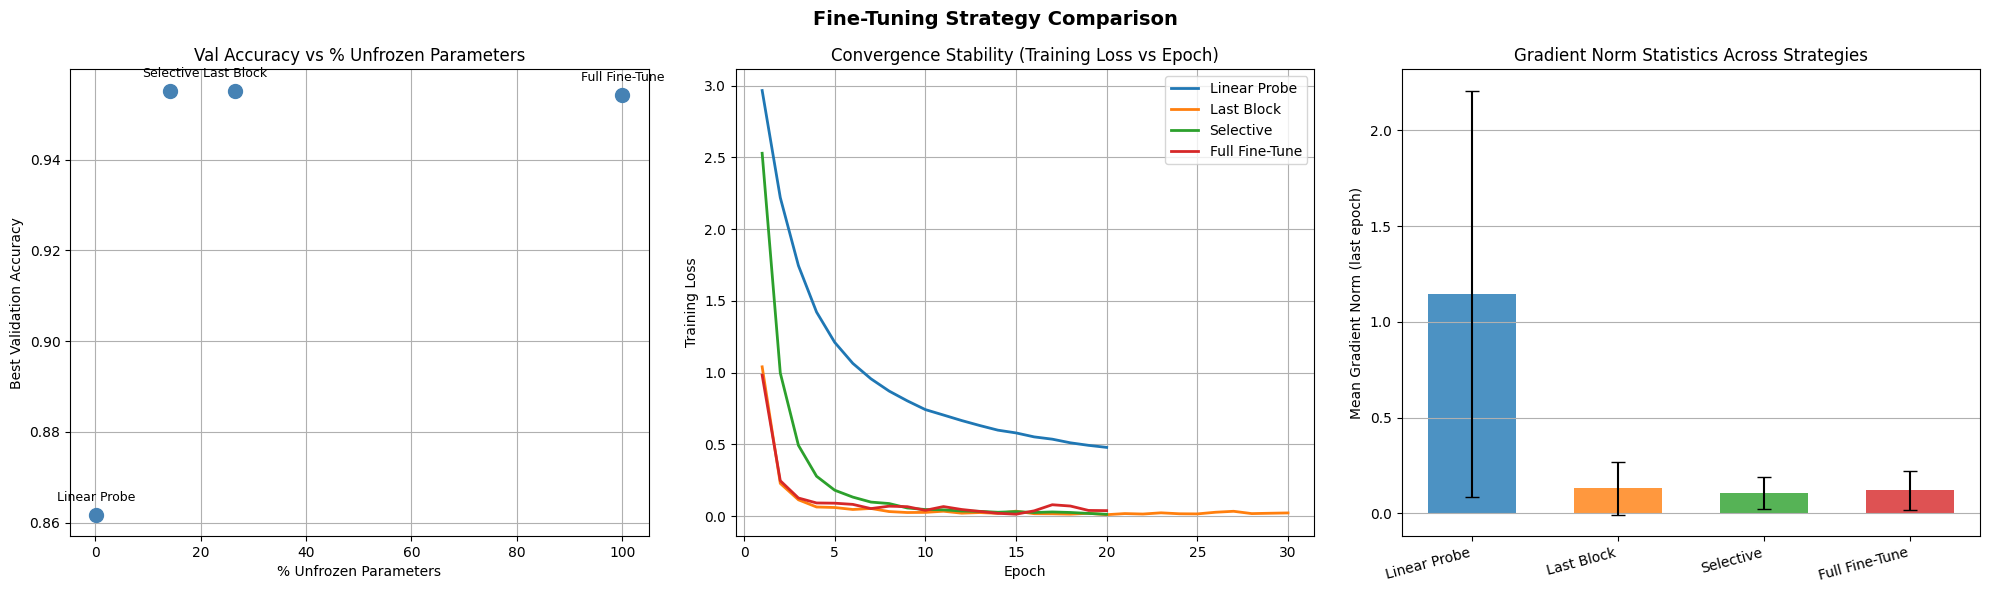

Saved resnet50_analysis.png


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_finetuning_analysis(history_files, out_name):
    """
    history_files: list of dicts, each with keys:
        - 'path'        : path to .pth history file
        - 'label'       : display name e.g. 'Linear Probe'
        - 'pct_unfrozen': float, % of unfrozen parameters e.g. 0.5
    """

    histories = []
    for hf in history_files:
        h = torch.load(hf['path'], map_location='cpu')
        h['label']       = hf['label']
        h['pct_unfrozen'] = hf['pct_unfrozen']
        histories.append(h)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Fine-Tuning Strategy Comparison', fontsize=14, fontweight='bold')

    # ─────────────────────────────────────────────
    # PLOT 1: Val accuracy vs % unfrozen parameters
    # ─────────────────────────────────────────────
    ax = axes[0]
    pcts     = [h['pct_unfrozen'] for h in histories]
    val_accs = [max(h['val_acc'])  for h in histories]
    labels   = [h['label']         for h in histories]

    ax.scatter(pcts, val_accs, marker='o', s=100, zorder=5, color='steelblue')
    for x, y, lbl in zip(pcts, val_accs, labels):
        ax.annotate(lbl, (x, y), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel('% Unfrozen Parameters')
    ax.set_ylabel('Best Validation Accuracy')
    ax.set_title('Val Accuracy vs % Unfrozen Parameters')
    ax.grid(True)

    # ─────────────────────────────────────────────
    # PLOT 2: Training loss vs epoch (convergence)
    # ─────────────────────────────────────────────
    ax = axes[1]
    for h in histories:
        ax.plot(range(1, len(h['train_loss']) + 1),
                h['train_loss'], label=h['label'], linewidth=2)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Convergence Stability (Training Loss vs Epoch)')
    ax.legend()
    ax.grid(True)

    # ─────────────────────────────────────────────
    # PLOT 3: Gradient norm statistics across layers
    # ─────────────────────────────────────────────
    ax = axes[2]

    # Use last epoch grad norms for each strategy
    x_positions = np.arange(len(histories))
    width        = 0.6

    for i, h in enumerate(histories):
        last_epoch_norms = h['grad_norms'][-1]  # dict {layer_name: norm}
        if not last_epoch_norms:
            continue
        norm_values = list(last_epoch_norms.values())
        mean_norm   = np.mean(norm_values)
        std_norm    = np.std(norm_values)
        ax.bar(i, mean_norm, width, yerr=std_norm,
               label=h['label'], capsize=5, alpha=0.8)

    ax.set_xticks(x_positions)
    ax.set_xticklabels([h['label'] for h in histories], rotation=15, ha='right')
    ax.set_ylabel('Mean Gradient Norm (last epoch)')
    ax.set_title('Gradient Norm Statistics Across Strategies')
    ax.grid(True, axis='y')

    plt.tight_layout()
    plt.savefig(out_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {out_name}")


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────

history_files = [
    {'path': 'resnet50_linearprobe_history.pth',  'label': 'Linear Probe',     'pct_unfrozen': 0.26},
    {'path': 'resnet50_lastblock_history.pth',    'label': 'Last Block',        'pct_unfrozen': 26.6},
    {'path': 'resnet50_selective_history.pth',    'label': 'Selective', 'pct_unfrozen': 14.3},
    {'path': 'resnet50_fullfinetune_history.pth', 'label': 'Full Fine-Tune',    'pct_unfrozen': 100.0},
]

plot_finetuning_analysis(history_files, "resnet50_analysis.png")

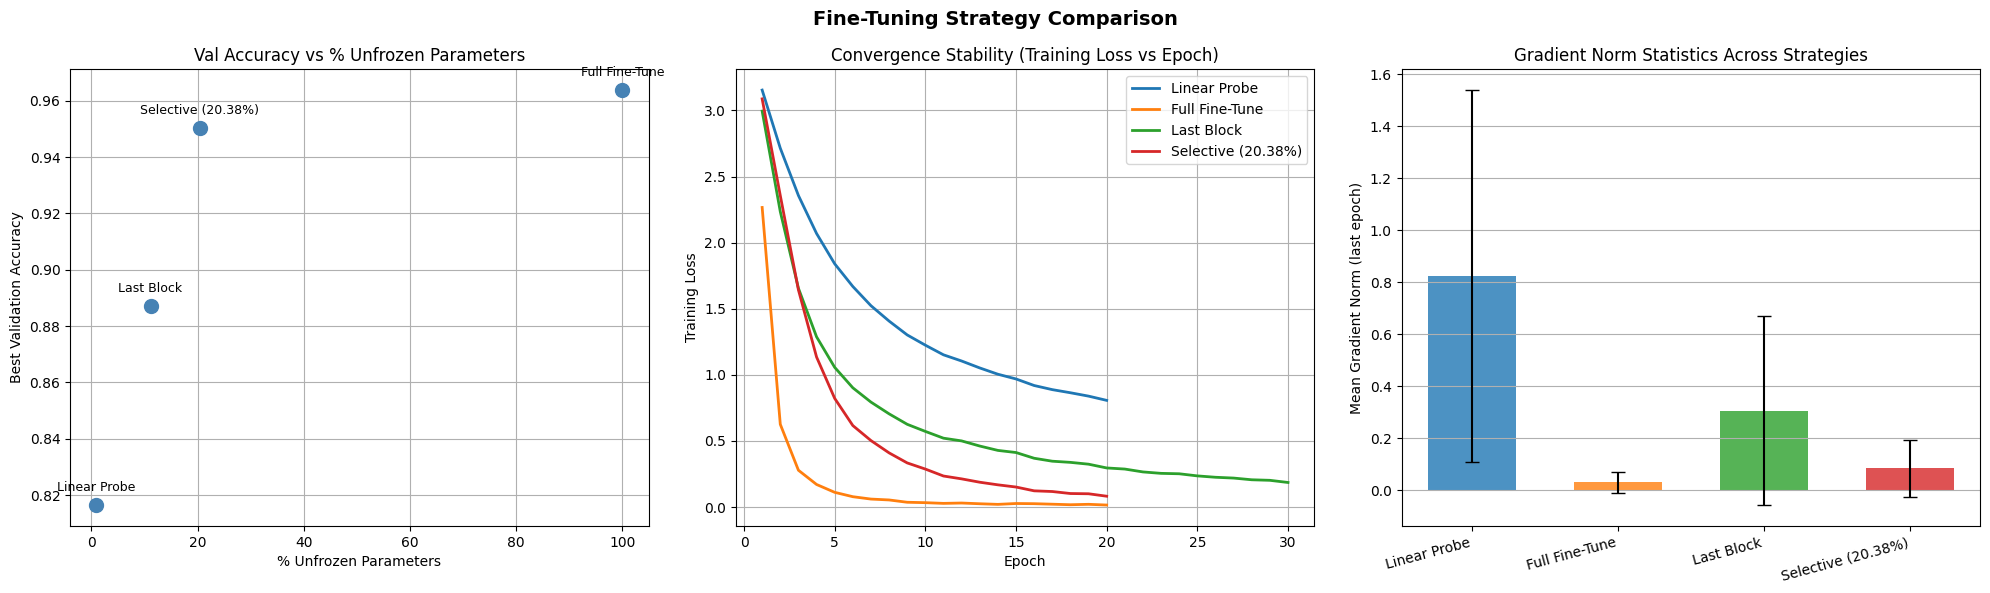

Saved efficientnet_b0_analysis.png


In [3]:
history_files = [
    {'path': 'efficientnet_b0_linearprobe_history.pth', 'label': 'Linear Probe',    'pct_unfrozen': 0.95},
    {'path': 'efficientnet_b0_fullfinetune_history.pth', 'label': 'Full Fine-Tune',    'pct_unfrozen': 100.0},
    {'path': 'efficientnet_b0_lastblock_history.pth',    'label': 'Last Block',        'pct_unfrozen': 11.14},
    {'path': 'efficientnet_b0_selective_history.pth',    'label': 'Selective (20.38%)', 'pct_unfrozen': 20.38},
]

plot_finetuning_analysis(history_files, "efficientnet_b0_analysis.png")

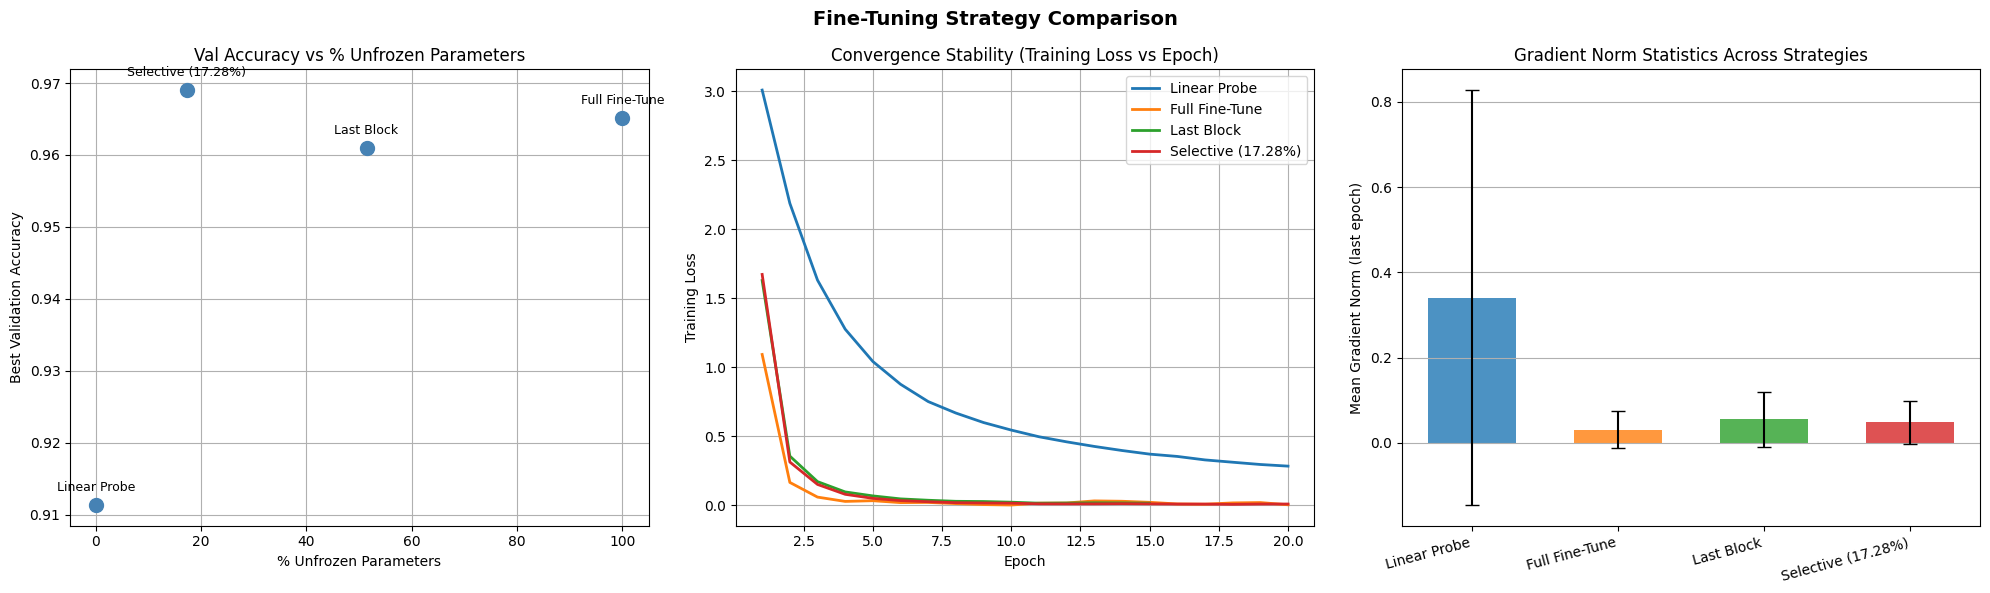

Saved efficientnet_b0_analysis.png


In [4]:
history_files = [
    {'path': 'convnext_tiny_linearprobe_history.pth', 'label': 'Linear Probe',    'pct_unfrozen': 0.09},
    {'path': 'convnext_tiny_fullfinetune_history.pth', 'label': 'Full Fine-Tune',    'pct_unfrozen': 100.0},
    {'path': 'convnext_tiny_lastblock_history.pth',    'label': 'Last Block',        'pct_unfrozen': 51.41},
    {'path': 'convnext_tiny_selective_history.pth',    'label': 'Selective (17.28%)', 'pct_unfrozen': 17.28},
]

plot_finetuning_analysis(history_files, "efficientnet_b0_analysis.png")